In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np

# Embeddings
drug_emb = np.load("Data/drug_chemberta_embeddings.npy")
adr_emb = np.load("Data/adr_bert_embeddings.npy")

# Names (for indexing)
cid_df = pd.read_csv("Data/drug_ids.csv")       # column: old_CID
adr_names = pd.read_csv("Data/adr_names.csv")    # column: ADR

# Positive drug-ADR pairs
df_meddra_all_se = pd.read_csv("Data/meddra_all_se.tsv", sep="\t", header=None)
print(df_meddra_all_se.head())
df_meddra_all_se.columns = ["CID", "STITCH_CID", "UMLS_ID", "Source", "Noname","ADR"]
df_meddra_all_se["new_CID"] = df_meddra_all_se["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)
df_meddra_all_indications = pd.read_csv("Data/meddra_all_indications.tsv", sep="\t", header=None,
                 names=["CID", "UMLS_ID", "text", "name", "name2","ID", "name4"])

df_meddra_all_indications["new_CID"] = df_meddra_all_indications["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)

CUI_list = df_meddra_all_se['UMLS_ID'].unique()
# drug_list = df_meddra_all_se["CID"].unique()


              0             1         2    3         4                      5
0  CID100000085  CID000010917  C0000729  LLT  C0000729       Abdominal cramps
1  CID100000085  CID000010917  C0000729   PT  C0000737         Abdominal pain
2  CID100000085  CID000010917  C0000737  LLT  C0000737         Abdominal pain
3  CID100000085  CID000010917  C0000737   PT  C0687713  Gastrointestinal pain
4  CID100000085  CID000010917  C0000737   PT  C0000737         Abdominal pain


In [2]:
cid_to_index = {cid: i for i, cid in enumerate(cid_df["CID"].tolist())}
adr_to_index = {adr: i for i, adr in enumerate(adr_names["ADR"].tolist())}
print(adr_to_index)
print(cid_to_index)


{'C0000729': 0, 'C0000737': 1, 'C0002418': 2, 'C0002871': 3, 'C0003123': 4, 'C0003467': 5, 'C0003811': 6, 'C0004093': 7, 'C0004238': 8, 'C0004604': 9, 'C0006277': 10, 'C0007222': 11, 'C0008031': 12, 'C0009450': 13, 'C0009806': 14, 'C0010200': 15, 'C0011570': 16, 'C0011991': 17, 'C0012833': 18, 'C0013378': 19, 'C0013395': 20, 'C0013404': 21, 'C0015230': 22, 'C0015397': 23, 'C0015967': 24, 'C0017152': 25, 'C0017178': 26, 'C0018681': 27, 'C0019080': 28, 'C0020437': 29, 'C0020461': 30, 'C0020517': 31, 'C0020538': 32, 'C0020649': 33, 'C0021400': 34, 'C0023218': 35, 'C0025222': 36, 'C0026826': 37, 'C0027497': 38, 'C0030193': 39, 'C0030252': 40, 'C0030517': 41, 'C0030554': 42, 'C0031350': 43, 'C0033774': 44, 'C0035078': 45, 'C0035455': 46, 'C0036572': 47, 'C0037199': 48, 'C0039231': 49, 'C0042029': 50, 'C0042373': 51, 'C0042571': 52, 'C0042963': 53, 'C0043094': 54, 'C0043096': 55, 'C0085595': 56, 'C0085649': 57, 'C0151735': 58, 'C0151736': 59, 'C0152020': 60, 'C0231528': 61, 'C0426576': 62, '

In [3]:
# rare_adr = []
# common_adr = []
# for adr in adr_names["ADR"]:
#   temp = se_df[se_df["ADR"]==adr]
#   if(temp.shape[0]<=5):
#     rare_adr.append(adr)
#   else:
#     common_adr.append(adr)
# print(len(rare_adr))


In [4]:

adr_counts = df_meddra_all_se["UMLS_ID"].value_counts()


rare_adr = adr_counts[adr_counts <= 5].index.tolist()
common_adr = adr_counts[adr_counts > 5].index.tolist()

print("Rare ADRs:", len(rare_adr))
print("Common ADRs:", len(common_adr))


Rare ADRs: 2661
Common ADRs: 3207


In [5]:
test_positive_data = []
# y_test = []

positive_data = []
# y_train = []
# (label = 1)
for _, row in df_meddra_all_se.iterrows():
    cid = row["new_CID"]
    adr = row["UMLS_ID"]

    i = cid_to_index.get(cid)
    j = adr_to_index.get(adr)

    if adr in rare_adr:
      if i is not None and j is not None and i < drug_emb.shape[0] and j < adr_emb.shape[0]:

        emb = np.concatenate([drug_emb[i], adr_emb[j]])
        test_positive_data.append(emb)
        # y_test.append(1)
    else:
       if i is not None and j is not None and i < drug_emb.shape[0] and j < adr_emb.shape[0]:

        emb = np.concatenate([drug_emb[i], adr_emb[j]])
        positive_data.append(emb)
        # y_train.append(1)




In [6]:
len(positive_data), len(test_positive_data)
# (294935, 6735)

(287565, 6693)

In [7]:
import ast
negative_data = []
count = 0
test_negative_data = []
for index, row in df_meddra_all_indications.iterrows():
    # if(count == 0):
        cid = row["new_CID"]
        adr = row["UMLS_ID"]

        i = cid_to_index.get(cid)
        j = adr_to_index.get(adr)
        if row['new_CID'] in cid_to_index.keys() and row['UMLS_ID'] in CUI_list and row['UMLS_ID'] not in rare_adr:
            
            if i is not None and j is not None and i < drug_emb.shape[0] and j < adr_emb.shape[0]:    
                emb = np.concatenate([drug_emb[i], adr_emb[j]])
            # print(emb[1:100])
            negative_data.append(emb)   
        elif row['new_CID'] in cid_to_index.keys() and row['UMLS_ID'] in CUI_list and row['UMLS_ID'] in rare_adr:  
            if i is not None and j is not None and i < drug_emb.shape[0] and j < adr_emb.shape[0]: 
                emb = np.concatenate([drug_emb[i], adr_emb[j]])
            # print(emb[1:100])
            test_negative_data.append(emb)  
len(negative_data), len(test_negative_data)

(22140, 2874)

In [ ]:
X_test = test_positive_data + test_negative_data
y_test = [1]*len(test_positive_data) + [0]*len(test_negative_data)

len(negative_data), len(X_test)

(22140, 22140, 9567)

In [9]:
X_train = positive_data + negative_data
y_train = [1] * len(positive_data) + [0]*len(negative_data)
len(X_train), len(y_train)

(309705, 309705)

In [10]:
import lightgbm as lgb
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X_test = np.array(X_test)
y_test = np.array(y_test)
X_train = np.array(X_train)
y_train = np.array(y_train)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = lgb.LGBMClassifier(
    is_unbalance = True,
    num_leaves=31,       
    max_depth=-1,         
    learning_rate=0.05,   
    n_estimators=100      
)


model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 287565, number of negative: 22140
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.824926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 391239
[LightGBM] [Info] Number of data points in the train set: 309705, number of used features: 1536
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.928513 -> initscore=2.564063
[LightGBM] [Info] Start training from score 2.564063


LGBMClassifier(is_unbalance=True, learning_rate=0.05)

In [11]:
import matplotlib.pyplot as plt

def analysis_func(y, y_hat, url=None):
    y = np.array(y, dtype=int)
    y_hat = np.array(y_hat, dtype=int)

    # confusion matrix
    TP = np.sum((y == 1) & (y_hat == 1))
    TN = np.sum((y == 0) & (y_hat == 0))
    FP = np.sum((y == 0) & (y_hat == 1))
    FN = np.sum((y == 1) & (y_hat == 0))

    values = {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}

    recall = round(TP / (TP + FN), 2) if (TP + FN) > 0 else 0.0
    precision = round(TP / (TP + FP), 2) if (TP + FP) > 0 else 0.0
    accuracy = round((TP + TN) / (TP + TN + FP + FN), 2)
    F1 = round((2 * recall * precision) / (recall + precision), 2) if (recall + precision) > 0 else 0.0

    result = {'values': values, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': F1}

    #draw the table
    data = [
        ["Predicted Negative", "Predicted Positive", ""],
        ['FN = ' + str(result['values']['FN']), 'TP = ' + str(result['values']['TP']), "Actual Positive"],
        ['TN = ' + str(result['values']['TN']), 'FP = ' + str(result['values']['FP']), "Actual Negative"]
    ]
    text = ""
    for key, val in result.items():
        if key != 'values':
            text += key + ': ' + str(val) + '    '

    fig, ax = plt.subplots(figsize=(8, 1.5))

    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=data, loc='center', cellLoc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(12)

    table.scale(1, 1.5)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('white')
        if(not(row == 0 and col == 2)):
            if( (row == 0 or col == 2)):
                cell.set_facecolor('#8d84d7')
            else:
                cell.set_facecolor('#ccc9e4')

    # plt.tight_layout(pad=0.01)
    plt.text(-.05, -.06, text)
    if(url != None):
        plt.savefig(url, dpi=200,bbox_inches='tight')
    plt.show()

    return result

In [12]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,auc,roc_curve, confusion_matrix,
    matthews_corrcoef
)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


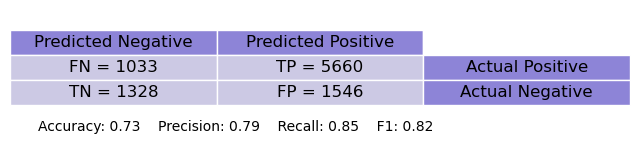

SP: 0.46207376478775225
MCC: 0.3272150873890216
AUR-PR: 0.8620849242771678
Accuracy: 0.7304275112365423
ROC-AUC: 0.7414388270714809


In [13]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
analysis_func(y_test, y_pred)

print("SP:", specificity_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("AUR-PR:",  average_precision_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

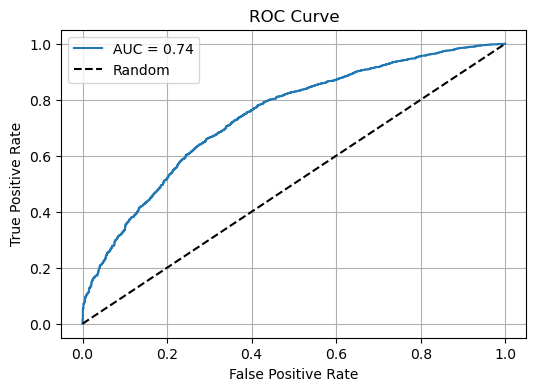

In [14]:

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()